In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

# Load data
df = pd.read_csv('AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Rename column for easier access if needed
df.columns = ['Passengers']

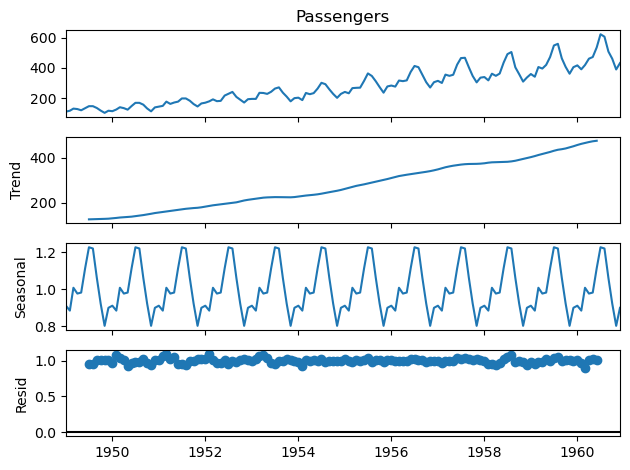

In [3]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')
decomposition.plot()
plt.show()

e:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


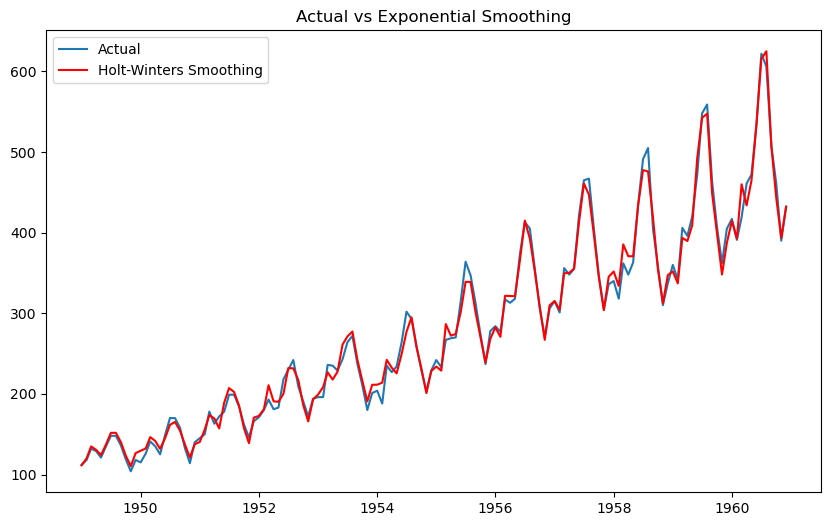

In [4]:
# Apply Triple Exponential Smoothing
df['HW_Smoothing'] = ExponentialSmoothing(df['Passengers'], trend='add', seasonal='mul', seasonal_periods=12).fit().fittedvalues

plt.figure(figsize=(10, 6))
plt.plot(df['Passengers'], label='Actual')
plt.plot(df['HW_Smoothing'], label='Holt-Winters Smoothing', color='red')
plt.legend()
plt.title('Actual vs Exponential Smoothing')
plt.show()

In [5]:
# Define and fit the SARIMA model
# (p,d,q) and (P,D,Q,s) parameters are chosen based on standard AirPassenger tuning
model = SARIMAX(df['Passengers'], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12))
results = model.fit()

# Forecast the next 24 months
forecast = results.get_forecast(steps=24)
forecast_df = forecast.summary_frame()

e:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
e:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Model RMSE: 15.56


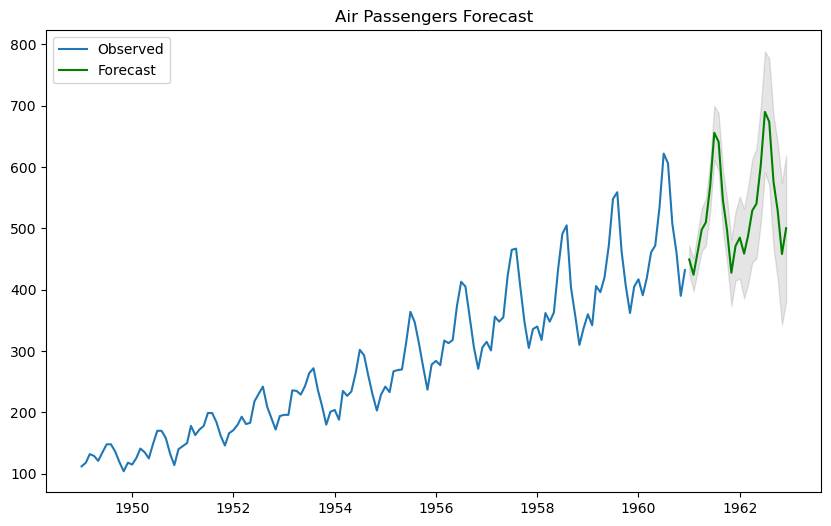

In [6]:
# Get predictions for the existing data to check accuracy
predictions = results.predict(start=0, end=len(df)-1)
rmse = np.sqrt(mean_squared_error(df['Passengers'], predictions))

print(f"Model RMSE: {rmse:.2f}")

# Visualize the Forecast
plt.figure(figsize=(10,6))
plt.plot(df['Passengers'], label='Observed')
plt.plot(forecast_df['mean'], label='Forecast', color='green')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='k', alpha=0.1)
plt.title('Air Passengers Forecast')
plt.legend()
plt.show()